<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# EDA del dataset de diabetes

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Description of the problem

This dataset originally comes from the National Institute of Diabetes and Digestive and Kidney Diseases. The goal is to predict, based on diagnostic measures, whether or not a patient has diabetes.

#### This EDA is going to share for tree-based algorithms
* Decision Tree
* Random Forest (Ensemble of Decision trees)
* Boosting or Sequential Decision Trees (XGBoost, AdaBoost, Gradient Boosting) 

#### Check to do in this EDA:
* Missing values check
* Duplicate rows check
* Target variable distribution (class imbalance)
* Feature data types (categorical encoding needed)
* Basic feature distributions (understanding, not transformation)

#### Checks I do NOT need to do in this EDA:

* Feature scaling/normalization
* Log or polynomial transformations
* Normality tests (Shapiro-Wilk, Q-Q plots)
* Removing outliers based on distribution
* VIF/multicollinearity checks
* Linearity assumptions

#### Consideration in tree-based algorithms
| **Aspect** | **Decision Tree** | **Random Forest** | **Boosting** |
|------------|-------------------|-------------------|--------------|
| **Overfitting** | High risk | Low risk (averaging) | Medium risk |
| **Feature importance** | Single tree | Averaged across trees | Sequential contribution |
| **Imbalance handling** | `class_weight` | `class_weight` | `scale_pos_weight` (XGBoost) |
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Import libraries and load dataset

</div>

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

# Libraries for preprocessing and Machine Learning 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Save the data
import os

# Set visualization style
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Se cargan los datos (usando sep=';' porque el archivo usa punto y coma como separador)
df = pd.read_csv('../data/raw/diabetes.csv', sep=',')
target_column = 'Outcome'
display(df.head())

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("Shape de df:", df.shape)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Columnas del dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Shape de df: (768, 9)


In [3]:
display(df.info())

print(f"\nAll variables are Numeric")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


All variables are Numeric


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">


* The dataframe has 369 columns and 9 variables. 

* All columns are numeric

##### Columns:

- **Pregnancies**: Most women have 0-6 pregnancies, but outliers go up to 17. Right-skewed distribution

- **Glucose**: Few outliers on both ends. Relatively normal distribution

- **Blood Pressure**: Many outliers, especially high values

- **Insulin**: EXTREME outliers reaching 600-800 .Most values clustered low. Highly right-skewed

- **BMI**: Some high outliers (60-70) .Most values between 25-40 .Few extreme obesity cases. 

- **SkinThickness**: Moderate outliers. Relatively symmetric. 

- **DiabetesPedigreeFunction**: Many small outliers .Concentrated near 0-1

- **Age**: Few outliers. Uniform distribution. Range 21-80 years

- **Outcome**: Binary (0 or 1). 0 -> Not diabetes and 1 diabetes.
</div>


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Step 2 - Analyze Dataset to Build a Decision Tree

#### Prepare and Analyze Data for Decision Tree Models

For Decision Tree, I do **NOT** need to check:
- I don´t need to check the Normality test (Shapito - Q-Q plots)
- Scaling/Standardization
- Log / Square transformation
- Outlier removal
- Multicollinearly checks
- Linearity asumptions

For Decision Tree, I need to check:
- Missing Values
- Duplicated rows
- Target Variable analysis ( Class imbalance detection)
- Feature Data type analysis (if there are categorical variables, I need to encode them)
- Feature Cardinality (for categorical features), high cardinality can lead to overfitting in Decision Trees. I need to check the number of unique categories and consider encoding strategies or dimensionality reduction if necessary.
- Metric seleccion - if the dataset is imbalanced, accuracy is not a good metric. We should use precision, recall or F1-score.


</div>


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Stadistic Metrics

</div>

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Missing Values Analysis

</div>

In [5]:
print("="*70)
print("MISSING VALUES")
print("="*70)

display(df.isnull().sum())

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

MISSING VALUES


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✓ No missing values found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Detect the duplicates
</div>

In [6]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Option 1: Keep first occurrence
    print("\nOptions for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")



DUPLICATE ROWS DETECTION

Total duplicate rows: 0
Percentage of duplicates: 0.00%

✓ No duplicate rows found in the dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Target Variable Analysis

Understanding the target variable is important for Decision Tree. We'll check:
- Class imbalance detection
- Metric seleccion - if the dataset is imbalanced, accuracy is not a good metric. We should use precision, recall or F1-score.

</div>

Target Variable: Outcome

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Imbalance Ratio: 34.90% / 65.10%


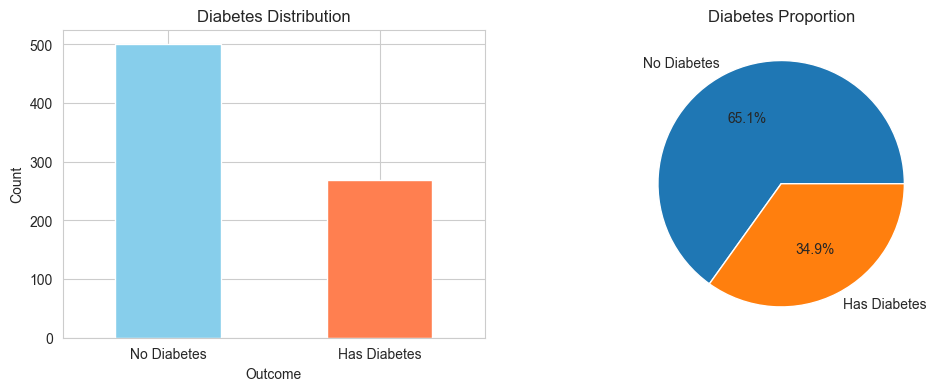

In [7]:
# For binary classification target
print(f"Target Variable: {target_column}")
print("="*60)

# Class distribution (MOST IMPORTANT)
print("\nClass Distribution:")
print(df[target_column].value_counts())
print("\nClass Proportions:")
print(df[target_column].value_counts(normalize=True))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart (better than histogram for categorical)
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Diabetes Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_xticklabels(['No Diabetes', 'Has Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   labels=['No Diabetes', 'Has Diabetes'])
axes[1].set_ylabel('')
axes[1].set_title('Diabetes Proportion')

# Check for imbalance
class_ratio = df[target_column].value_counts(normalize=True)
print(f"\nImbalance Ratio: {class_ratio.min():.2%} / {class_ratio.max():.2%}")
if class_ratio.min() < 0.3:
    print("Class imbalance detected - consider balancing techniques")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Consideration to use Balancing Techniques
As the Imbalance ration is 35/65, I will consider using balancing techniques to improve the performance of the Decision Tree model. I will evaluate the performance of the model with and without balancing techniques to determine if it is necessary in this case.

I can use techniques like:
- Using class weights in the Decision Tree model to give more importance to the minority class  
- Oversampling, Undersampling or SMOTE. As the imbalance ratio is not high, I am not going to use this technique
- Choose better metrics: In imbalanced datasets, accuracy can be misleading. Instead, I will focus on metrics like precision, recall, F1-score, and the area under the ROC curve (AUC-ROC) to evaluate the performance of the model.
- Adjusting the decision threshold: Instead of using the default threshold of 0.5 for classifying samples, I can adjust the threshold to optimize for precision or recall, depending on the specific requirements of the problem.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature Data Types
All the data are numeric, I don´t need to encode any categorical variable. I can use the data as they are for the Decision Tree model.
</div

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Correlation Analysis

Correlation analysis for decision tree is not necessary, but we can reduce the number of variables and improve the performance

</div

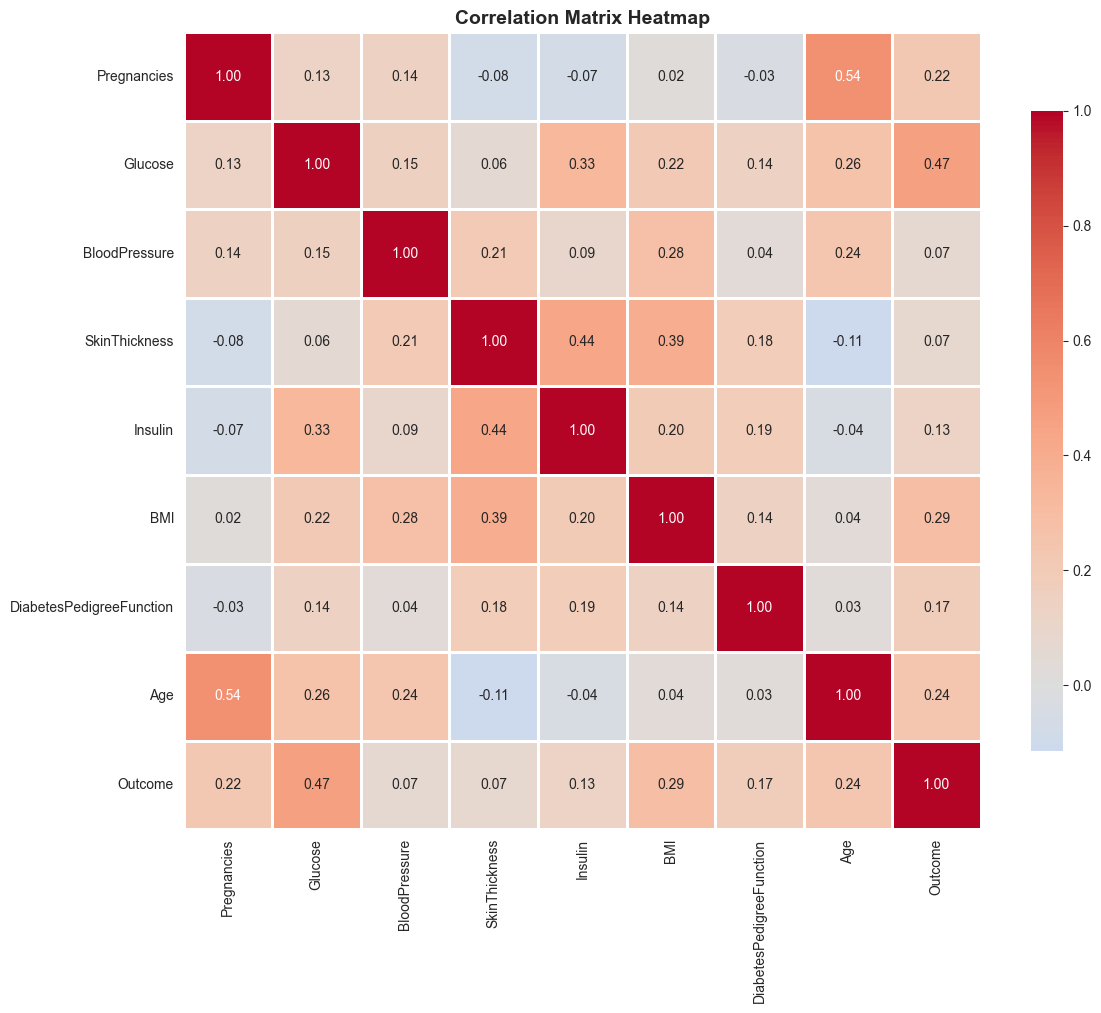


Identify strong correlations (|r| > 0.7)


In [8]:
# Visualize correlation matrix with heatmap
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")


Feature Correlations with Target Variable: Outcome
• Glucose              | r =  0.467
• BMI                  | r =  0.293
• Age                  | r =  0.238
• Pregnancies          | r =  0.222
• DiabetesPedigreeFunction | r =  0.174
• Insulin              | r =  0.131
• SkinThickness        | r =  0.075
• BloodPressure        | r =  0.065


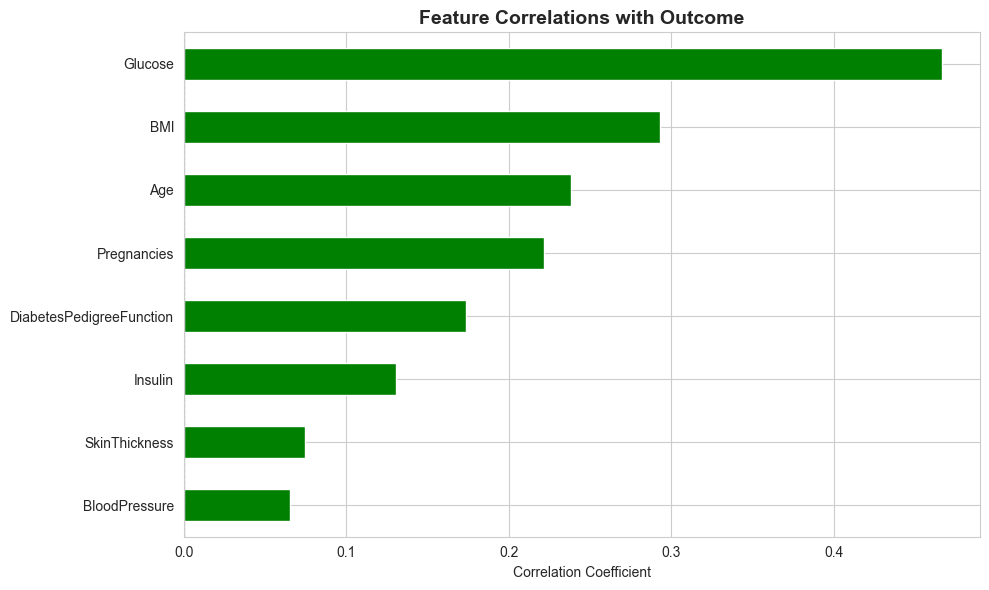

In [9]:
# Feature correlations with target variable
target_correlations = correlation_matrix[target_column].drop(target_column)

# Sort by absolute value (strongest correlations first)
target_correlations_sorted = target_correlations.reindex(target_correlations.abs().sort_values(ascending=True).index)

print("\n" + "="*70)
print(f"Feature Correlations with Target Variable: {target_column}")
print("="*70)
for feature, corr_value in target_correlations.abs().sort_values(ascending=False).items():
    actual_corr = target_correlations[feature]
    print(f"• {feature:20} | r = {actual_corr:>6.3f}")

# Bar plot of correlations with target (highest at top)
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_correlations_sorted.values]
target_correlations_sorted.plot(kind='barh', color=colors)
plt.title(f'Feature Correlations with {target_column}', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature Distributions


</div

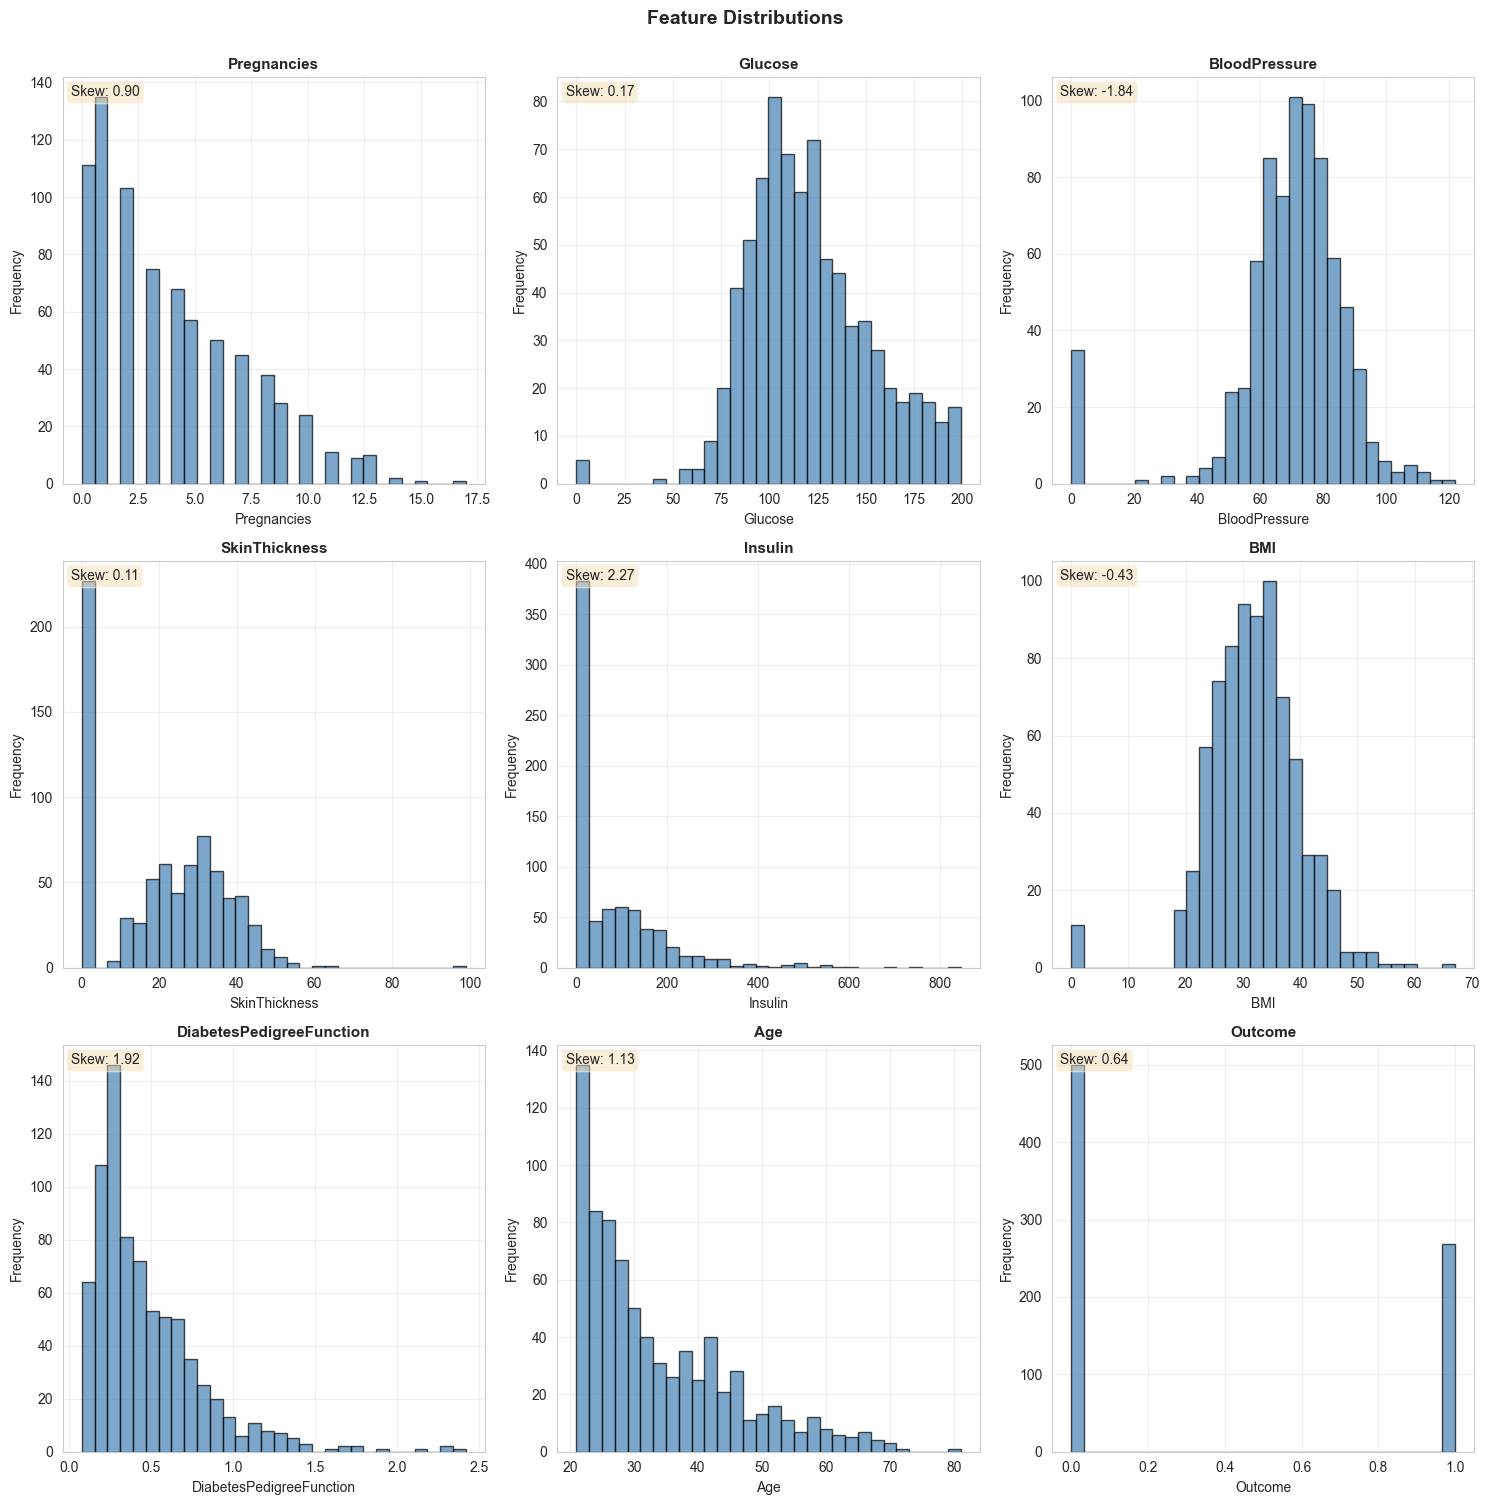

In [10]:
# Histogram for all numeric features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skewness = df[col].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Insulin and SinThickness have a high concentration of zers or low values
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Feature vs Target Relationships
Boxplots comparing feature distributions between diabetic and non-diabetic patients. This helps identify which features show clear separation between classes.
</div>

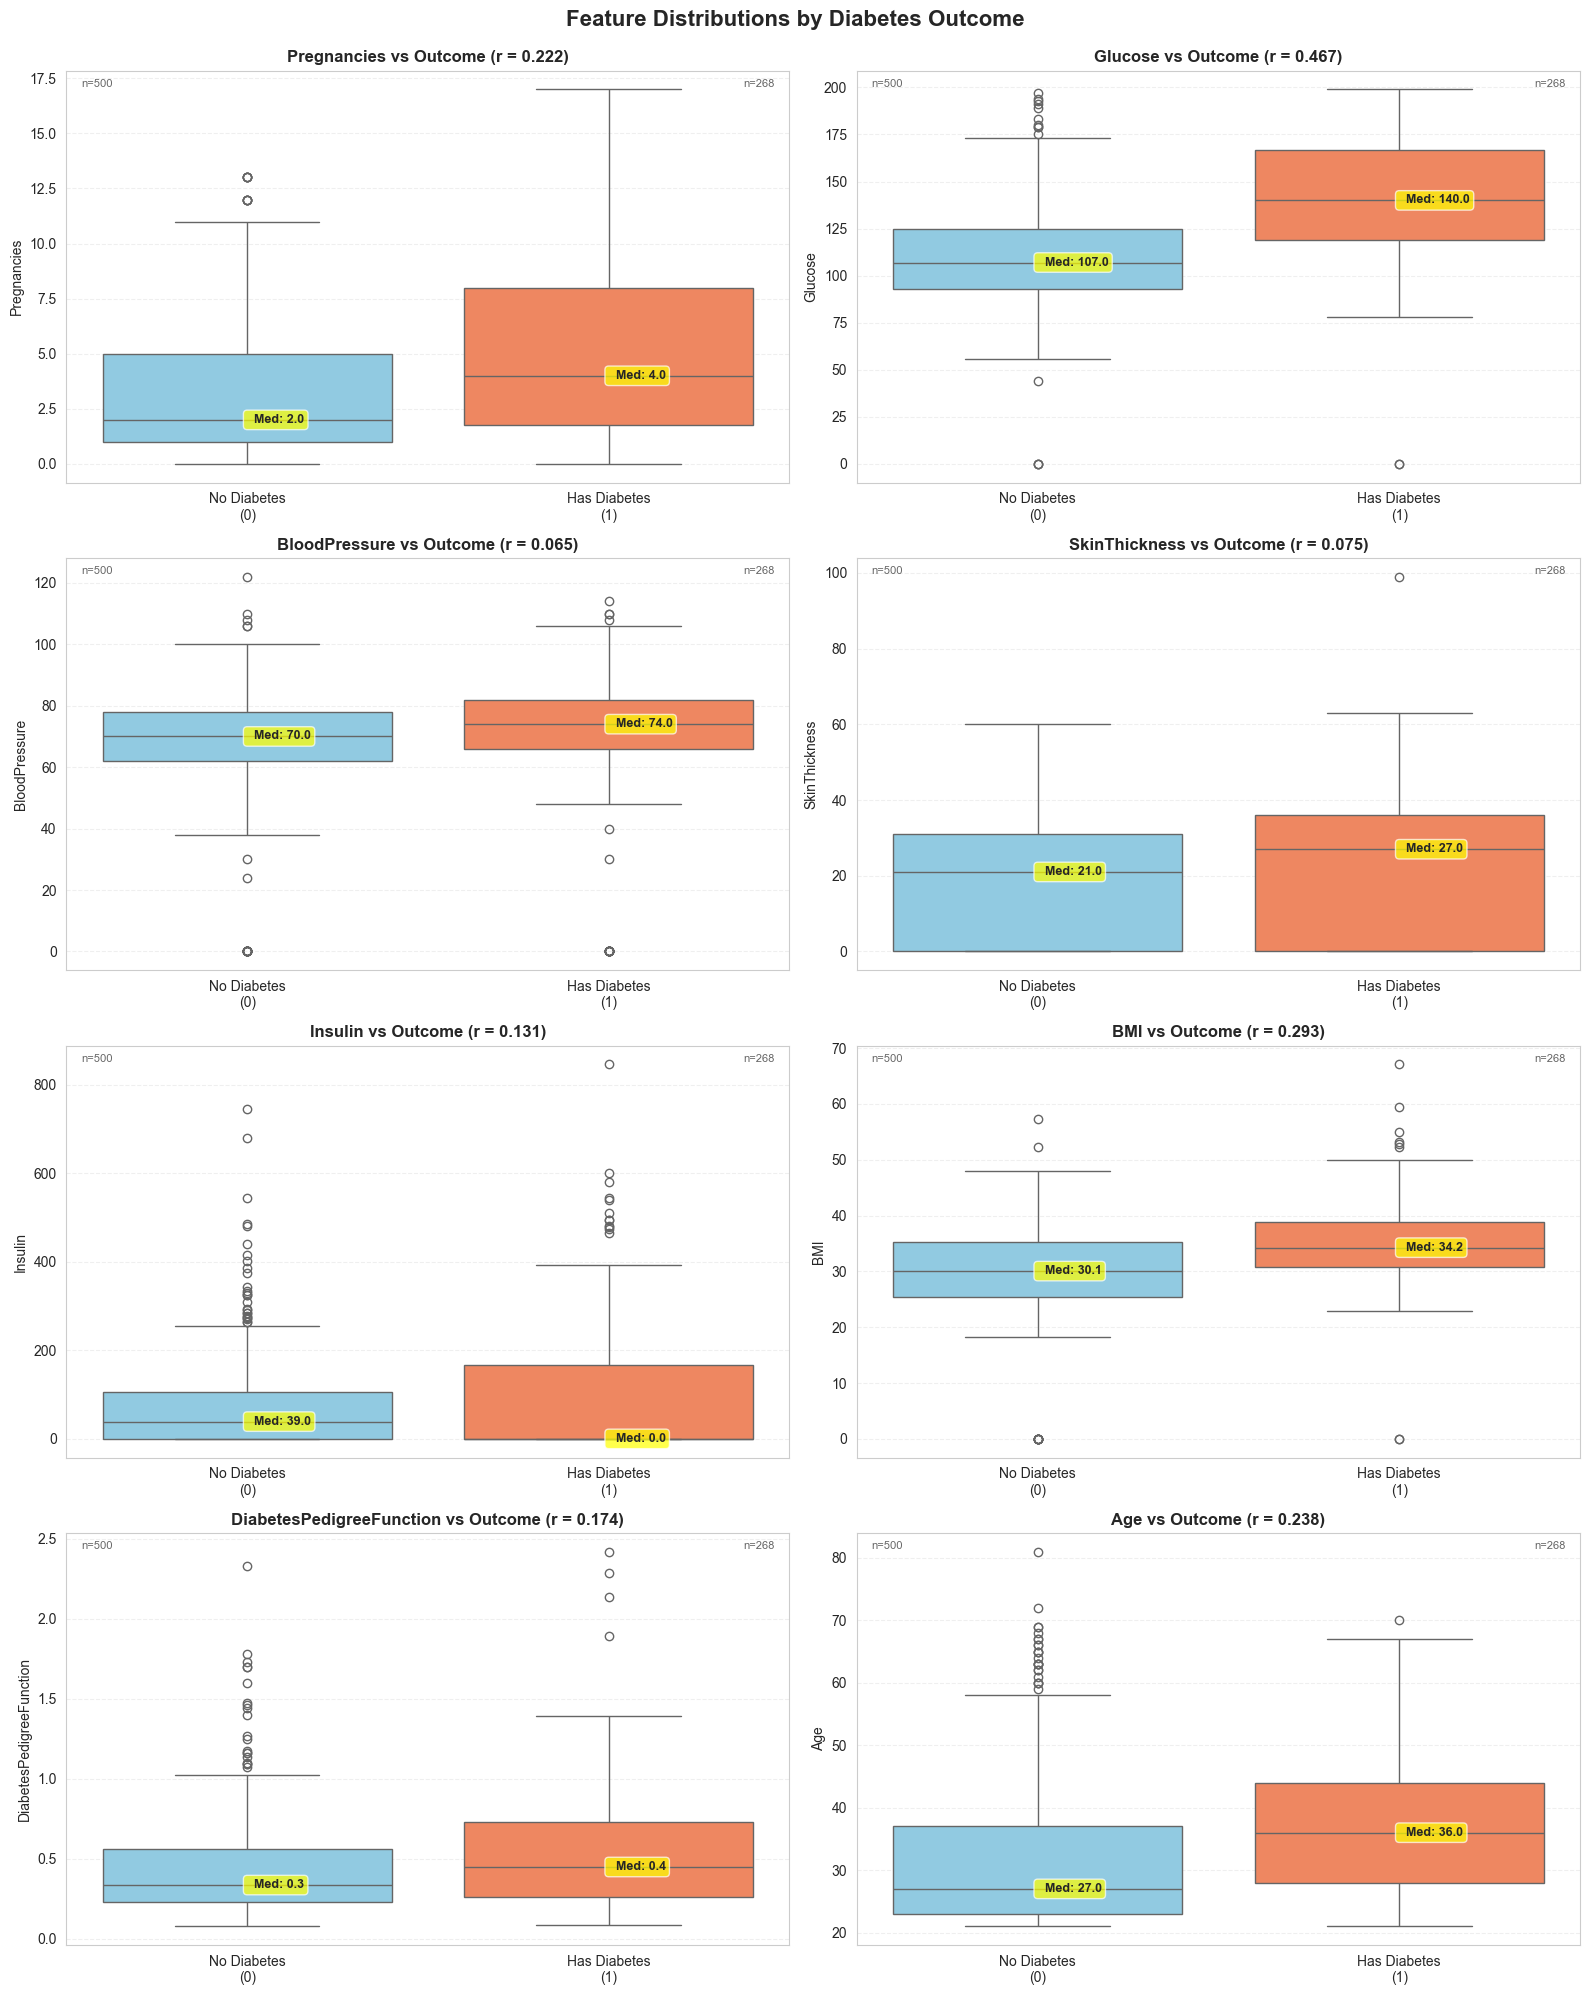

In [11]:
# Boxplots: Features vs Target (comparing distributions by diabetes status)
features_to_plot = [f for f in numeric_features if f != target_column]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# Define colors for each outcome
colors = ['skyblue', 'coral']  # 0: No Diabetes (blue), 1: Has Diabetes (coral)

# Calculate sample sizes once
n_no_diabetes = (df['Outcome'] == 0).sum()
n_has_diabetes = (df['Outcome'] == 1).sum()

for i, col in enumerate(features_to_plot):
    # Create boxplot with custom colors
    bp = sns.boxplot(data=df, x="Outcome", y=col, ax=axes[i], palette=colors, saturation=0.8)
    
    # Improve title with correlation coefficient
    corr = df[col].corr(df[target_column])
    axes[i].set_title(f'{col} vs Outcome (r = {corr:.3f})', fontsize=12, fontweight='bold')
    
    # Better axis labels
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No Diabetes\n(0)', 'Has Diabetes\n(1)'])
    axes[i].set_ylabel(col, fontsize=10)
    
    # Add grid for easier reading
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add sample sizes
    axes[i].text(0.02, 0.98, f'n={n_no_diabetes}', transform=axes[i].transAxes,
                 va='top', ha='left', fontsize=8, alpha=0.7)
    axes[i].text(0.98, 0.98, f'n={n_has_diabetes}', transform=axes[i].transAxes,
                 va='top', ha='right', fontsize=8, alpha=0.7)
    
    # Calculate and display median values for each group
    medians = df.groupby('Outcome')[col].median()
    for j, (outcome, median_val) in enumerate(medians.items()):
        axes[i].text(j, median_val, f'  Med: {median_val:.1f}', 
                     ha='left', va='center', fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Pairplot (Relationships Overview)
Visualize all pairwise relationships at once.
</div>

Creating pairplot for: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


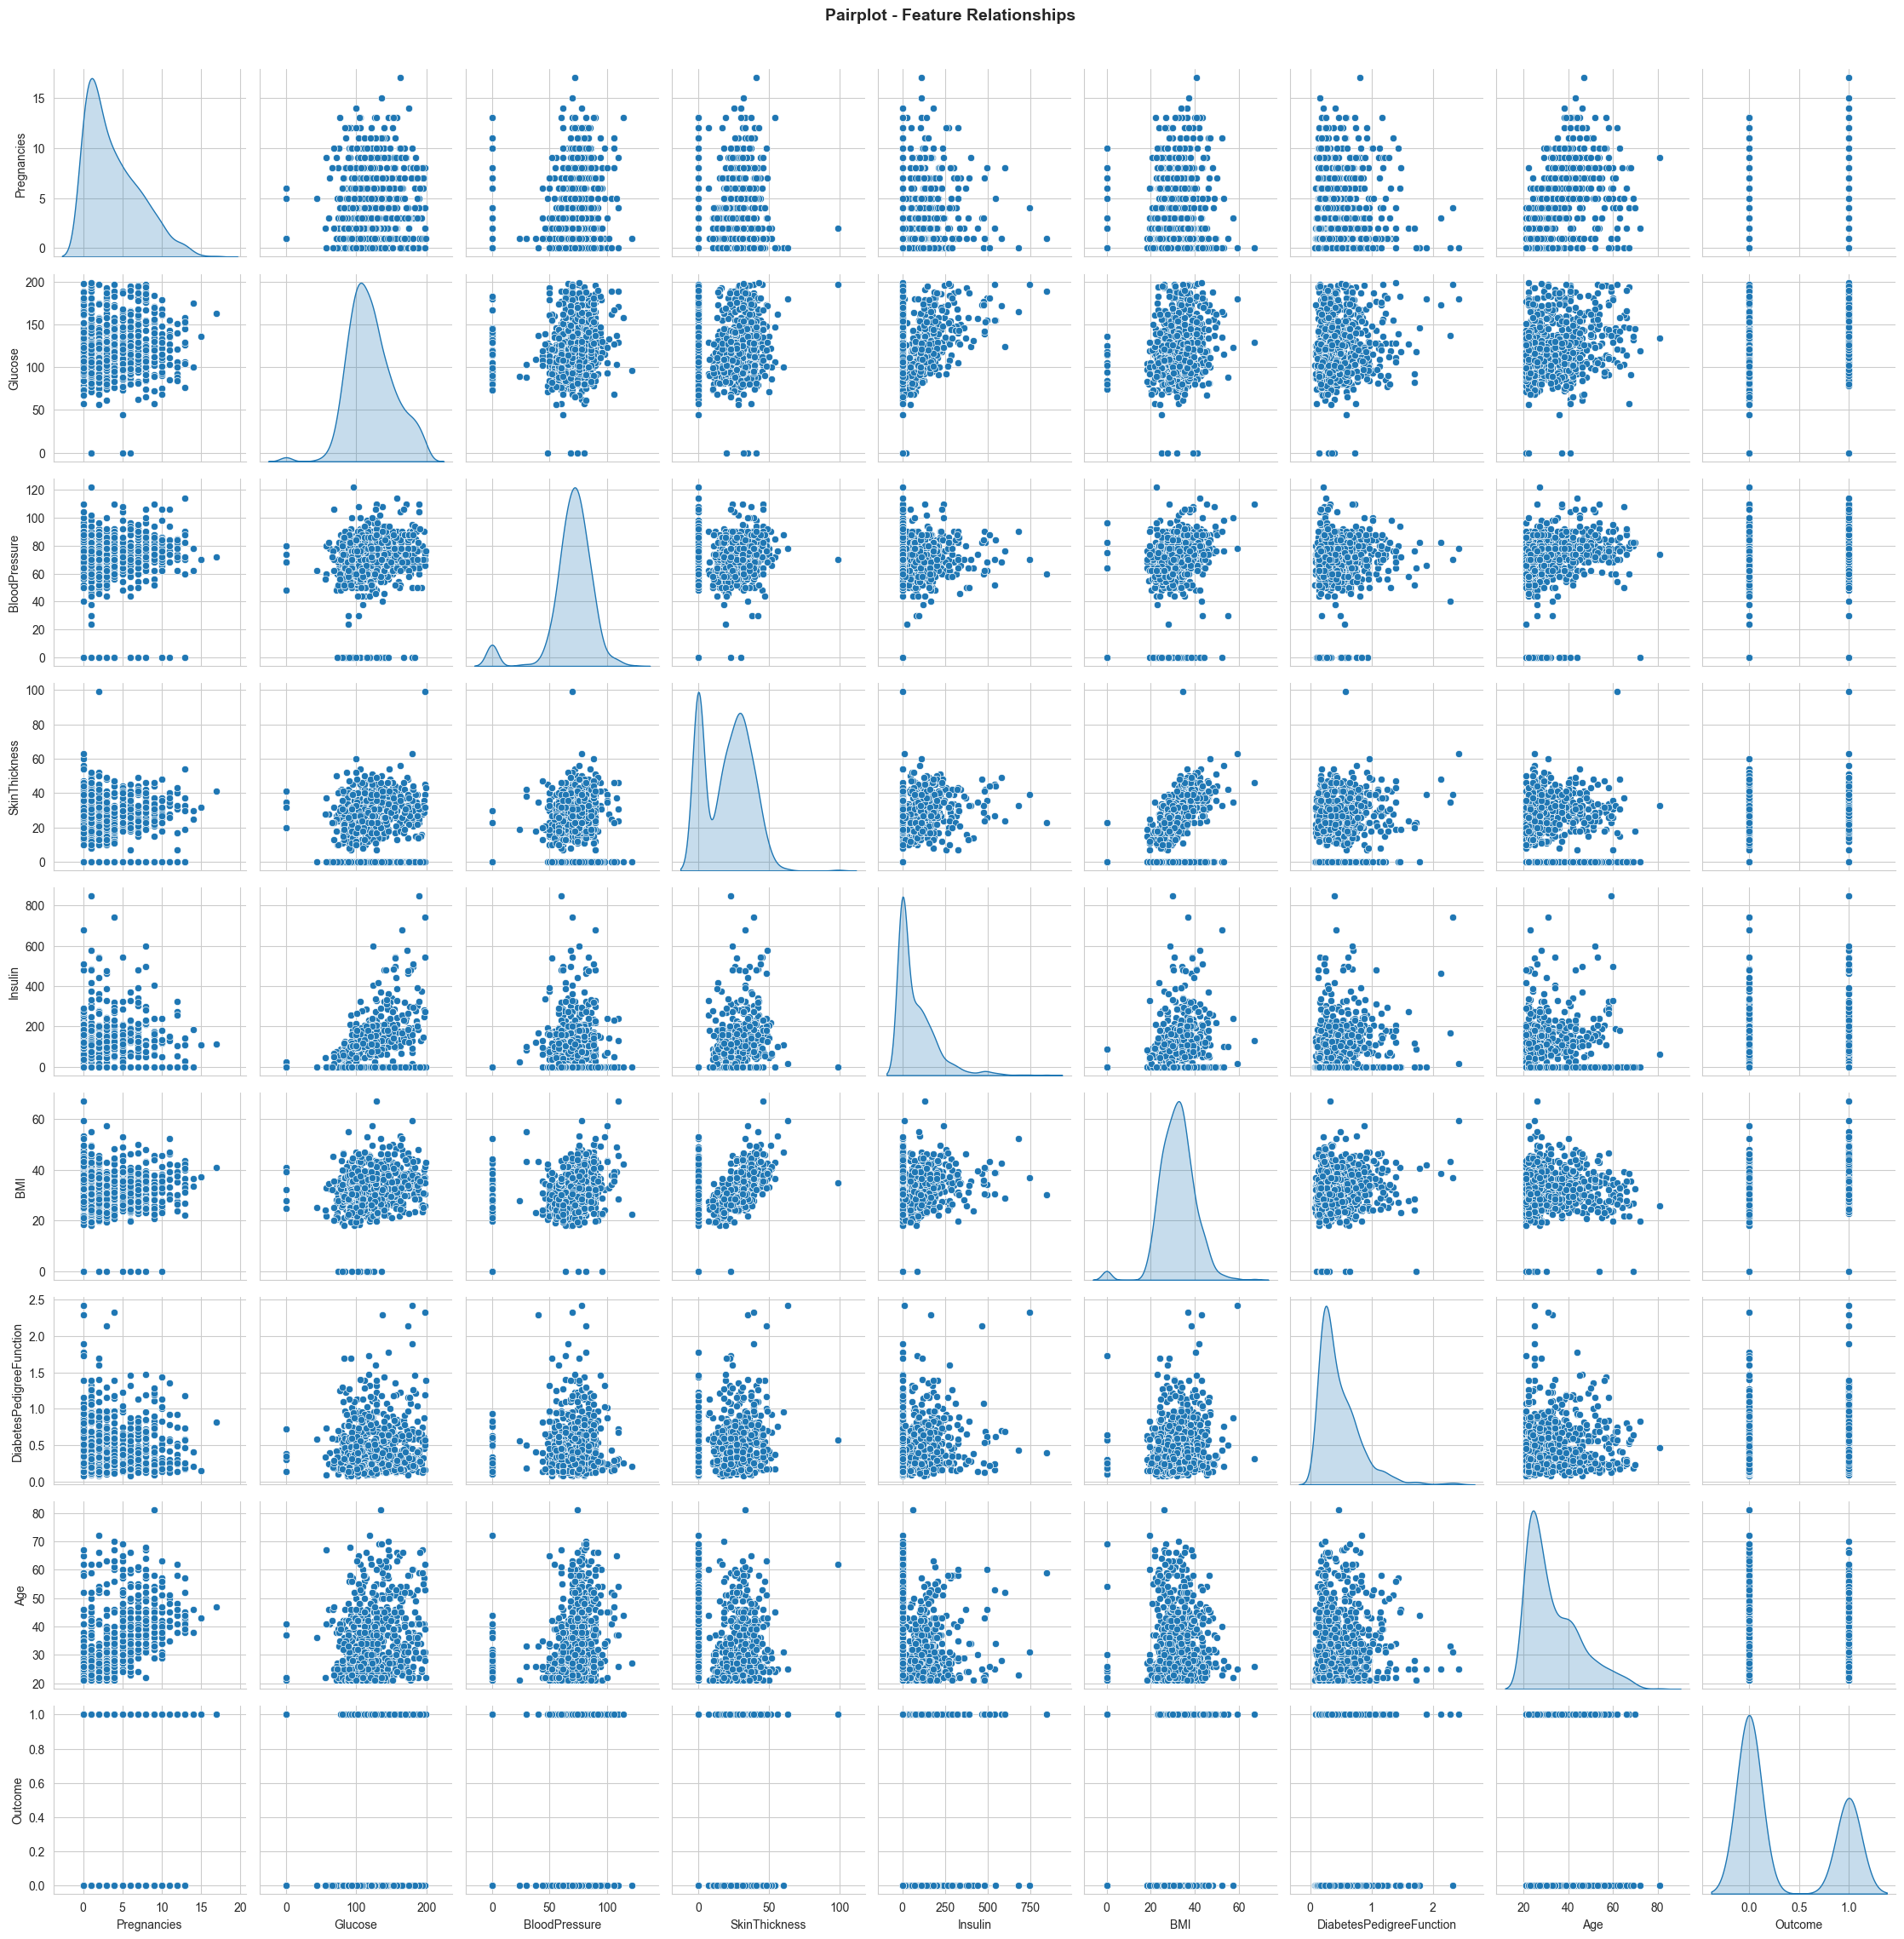

In [12]:
# Pairplot for numeric features (limit to avoid overcrowding)

print(f"Creating pairplot for: {numeric_features}")
sns.pairplot(df[numeric_features], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

This pairplot reveals several important insights about your data:

* **BloodPressure**: Normal-ish with spike near 0 - Zero values = missing data!
* **SkinThickness**: Massive spike at 0, then spread - Many zeros = missing data!
* **Insulin**: HUGE spike at 0, long right tail - Many zeros = missing data!

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Data Preprocessing - Handle Zeros

* Change zeros to Nan
* Change Nan to Median
</div>

In [13]:
# 1. Handle missing data (zeros)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Calculate zero counts for all columns
zero_counts = {}
for col in cols_with_zeros:
    zero_counts[col] = (df[col] == 0).sum()

# Sort by number of zeros (descending - most zeros first)
sorted_zeros = sorted(zero_counts.items(), key=lambda x: x[1], reverse=True)

# Print results ordered from biggest to smallest
print("="*70)
print("ZERO VALUES ANALYSIS (Ordered by frequency)")
print("="*70)
for col, zero_count in sorted_zeros:
    percentage = zero_count/len(df)*100
    print(f"{col:20} | {zero_count:3} zeros ({percentage:5.1f}%)")

ZERO VALUES ANALYSIS (Ordered by frequency)
Insulin              | 374 zeros ( 48.7%)
SkinThickness        | 227 zeros ( 29.6%)
BloodPressure        |  35 zeros (  4.6%)
BMI                  |  11 zeros (  1.4%)
Glucose              |   5 zeros (  0.7%)


In [14]:
# Create a copy of the original dataset
df_processed = df.copy()

print("="*70)
print("DATA PREPROCESSING PIPELINE")
print("="*70)

# Step 1: Identify columns with zero values that represent missing data
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Sort by number of zeros (descending - most zeros first)
sorted_zeros = sorted(zero_counts.items(), key=lambda x: x[1], reverse=True)

print("\nStep 1: Checking zero values (missing data)")
print("-"*70)
zero_counts = {}
for col, zero_count in sorted_zeros:
    percentage = zero_count/len(df)*100
    print(f"{col:20} | {zero_count:3} zeros ({percentage:5.1f}%)")

# Step 2: Replace zeros with NaN
print("\nStep 2: Replacing zeros with NaN")
print("-"*70)
for col in cols_to_impute:
    df_processed[col] = df_processed[col].replace(0, np.nan)
    nan_count = df_processed[col].isnull().sum()
    print(f"   {col:20} {nan_count:4} NaN values")

print(f"\n✓ Total rows with any missing values: {df_processed.isnull().any(axis=1).sum()}")
print(f"✓ Dataset shape: {df_processed.shape}")

DATA PREPROCESSING PIPELINE

Step 1: Checking zero values (missing data)
----------------------------------------------------------------------
Insulin              | 374 zeros ( 48.7%)
SkinThickness        | 227 zeros ( 29.6%)
BloodPressure        |  35 zeros (  4.6%)
BMI                  |  11 zeros (  1.4%)
Glucose              |   5 zeros (  0.7%)

Step 2: Replacing zeros with NaN
----------------------------------------------------------------------
   Glucose                 5 NaN values
   BloodPressure          35 NaN values
   SkinThickness         227 NaN values
   Insulin               374 NaN values
   BMI                    11 NaN values

✓ Total rows with any missing values: 376
✓ Dataset shape: (768, 9)


In [15]:
# Impute missing values with median
print("\n" + "="*70)
print("IMPUTATION STRATEGY: MEDIAN")
print("="*70)

# Calculate and display medians BEFORE imputation (excluding NaN)
print("\nMedian values used for imputation:")
print("-"*70)
medians = {}
for col in cols_to_impute:
    median_value = df_processed[col].median()
    medians[col] = median_value
    print(f"   {col:20} Median = {median_value:.2f}")

# Perform imputation
imputer = SimpleImputer(strategy='median')
df_processed[cols_to_impute] = imputer.fit_transform(df_processed[cols_to_impute])

# Verify no missing values remain
print("\nVerification after imputation:")
print("-"*70)
missing_after = df_processed.isnull().sum().sum()
print(f"   Total missing values: {missing_after}")
if missing_after == 0:
    print("   ✓ All missing values successfully imputed!")
else:
    print(f"   ⚠ Warning: {missing_after} missing values still remain")

# Display summary statistics after imputation
print("\n📈 Dataset summary after preprocessing:")
print("-"*70)
print(f"   Total rows: {len(df_processed)}")
print(f"   Total columns: {len(df_processed.columns)}")
print(f"   Features: {len(df_processed.columns) - 1}")  # Excluding target
print(f"   Target: {target_column}")


IMPUTATION STRATEGY: MEDIAN

Median values used for imputation:
----------------------------------------------------------------------
   Glucose              Median = 117.00
   BloodPressure        Median = 72.00
   SkinThickness        Median = 29.00
   Insulin              Median = 125.00
   BMI                  Median = 32.30

Verification after imputation:
----------------------------------------------------------------------
   Total missing values: 0
   ✓ All missing values successfully imputed!

📈 Dataset summary after preprocessing:
----------------------------------------------------------------------
   Total rows: 768
   Total columns: 9
   Features: 8
   Target: Outcome


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Train-Test Split

Split the data into training and testing sets while maintaining class distribution. Use stratify to maintain 80/20 for the target column in test and training dataset.

</div>

In [16]:
X = df_processed.drop(columns="Outcome")
y = df_processed["Outcome"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X: (768, 8)
Shape de y: (768,)
Shape de X_train: (614, 8)
Shape de X_test: (154, 8)
Shape de y_train: (614,)
Shape de y_test: (154,)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Save the dataset to use for the tree based algorithms

</div>

In [17]:

# Define output directory
processed_path = "../data/processed/03-diabetes"

# Create directory if it doesn't exist
os.makedirs(processed_path, exist_ok=True)

print("="*70)
print("SAVING PROCESSED DATA")
print("="*70)
print(f"\n📁 Output directory: {processed_path}\n")

# Save files with progress tracking
files_saved = []

# 1. Full processed dataset
df_processed.to_csv(f"{processed_path}/diabetes_ready.csv", index=False)
files_saved.append(("diabetes_ready.csv", df_processed.shape))
print(f"✓ diabetes_ready.csv       | {df_processed.shape[0]:3} rows × {df_processed.shape[1]} cols")

# 2. Training features
X_train.to_csv(f"{processed_path}/X_train.csv", index=False)
files_saved.append(("X_train.csv", X_train.shape))
print(f"✓ X_train.csv              | {X_train.shape[0]:3} rows × {X_train.shape[1]} cols")

# 3. Test features
X_test.to_csv(f"{processed_path}/X_test.csv", index=False)
files_saved.append(("X_test.csv", X_test.shape))
print(f"✓ X_test.csv               | {X_test.shape[0]:3} rows × {X_test.shape[1]} cols")

# 4. Training target
y_train.to_frame(name="Outcome").to_csv(f"{processed_path}/y_train.csv", index=False)
files_saved.append(("y_train.csv", (len(y_train), 1)))
print(f"✓ y_train.csv              | {len(y_train):3} rows × 1 col")

# 5. Test target
y_test.to_frame(name="Outcome").to_csv(f"{processed_path}/y_test.csv", index=False)
files_saved.append(("y_test.csv", (len(y_test), 1)))
print(f"✓ y_test.csv               | {len(y_test):3} rows × 1 col")

print("\n" + "="*70)
print(f"✅ SUCCESS: {len(files_saved)} files saved to {processed_path}")
print("="*70)

SAVING PROCESSED DATA

📁 Output directory: ../data/processed/03-diabetes

✓ diabetes_ready.csv       | 768 rows × 9 cols
✓ X_train.csv              | 614 rows × 8 cols
✓ X_test.csv               | 154 rows × 8 cols
✓ y_train.csv              | 614 rows × 1 col
✓ y_test.csv               | 154 rows × 1 col

✅ SUCCESS: 5 files saved to ../data/processed/03-diabetes
